# Big Data Analysis Using PySpark

## CodTech Data Analysis Internship - Task 1

### Project Overview

Big Data Analysis involves processing and analyzing large datasets to extract meaningful insights and support data-driven decision making.

In this project, Apache Spark (PySpark) is used to analyze Walmart sales data. PySpark enables scalable data processing and efficient handling of large datasets.

The analysis focuses on sales trends, store performance, holiday impact on sales, and business insights derived from the dataset.

### Objective

To perform scalable data analysis using PySpark and generate meaningful business insights from Walmart sales data.

### Tools and Technologies Used

- Python
- Google Colab
- PySpark
- Pandas
- Matplotlib
- Seaborn

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Install and Configure PySpark
!pip install pyspark

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Walmart Big Data Analysis") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [6]:
# Load Dataset
df = pd.read_csv("Walmart.csv")

In [7]:
df = spark.read.csv(
    "Walmart.csv",
    header=True,
    inferSchema=True
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [8]:
df.show(5)

+-----+----------+------------+------------+-----------+----------+-----------+------------+
|Store|      Date|Weekly_Sales|Holiday_Flag|Temperature|Fuel_Price|        CPI|Unemployment|
+-----+----------+------------+------------+-----------+----------+-----------+------------+
|    1|05-02-2010|   1643690.9|           0|      42.31|     2.572|211.0963582|       8.106|
|    1|12-02-2010|  1641957.44|           1|      38.51|     2.548|211.2421698|       8.106|
|    1|19-02-2010|  1611968.17|           0|      39.93|     2.514|211.2891429|       8.106|
|    1|26-02-2010|  1409727.59|           0|      46.63|     2.561|211.3196429|       8.106|
|    1|05-03-2010|  1554806.68|           0|       46.5|     2.625|211.3501429|       8.106|
+-----+----------+------------+------------+-----------+----------+-----------+------------+
only showing top 5 rows


In [9]:
df.printSchema()

root
 |-- Store: integer (nullable = true)
 |-- Date: string (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- Holiday_Flag: integer (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- CPI: double (nullable = true)
 |-- Unemployment: double (nullable = true)



In [11]:
print("Total Rows:", df.count())

Total Rows: 6435


In [12]:
print("Total Columns:", len(df.columns))

Total Columns: 8


In [13]:
# Data Exploration
print(df.columns)

['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


In [14]:
df.describe().show()

+-------+------------------+----------+------------------+-------------------+------------------+-------------------+-----------------+------------------+
|summary|             Store|      Date|      Weekly_Sales|       Holiday_Flag|       Temperature|         Fuel_Price|              CPI|      Unemployment|
+-------+------------------+----------+------------------+-------------------+------------------+-------------------+-----------------+------------------+
|  count|              6435|      6435|              6435|               6435|              6435|               6435|             6435|              6435|
|   mean|              23.0|      NULL|1046964.8775617732|0.06993006993006994| 60.66378243978229|  3.358606837606832|171.5783938487799| 7.999151048951067|
| stddev|12.988182381175454|      NULL| 564366.6220536977| 0.2550489443698279|18.444932875811585|0.45901970719285223|39.35671229566419|1.8758847818627944|
|    min|                 1|01-04-2011|         209986.25|            

In [15]:
from pyspark.sql.functions import col, when, count

df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in df.columns
]).show()

+-----+----+------------+------------+-----------+----------+---+------------+
|Store|Date|Weekly_Sales|Holiday_Flag|Temperature|Fuel_Price|CPI|Unemployment|
+-----+----+------------+------------+-----------+----------+---+------------+
|    0|   0|           0|           0|          0|         0|  0|           0|
+-----+----+------------+------------+-----------+----------+---+------------+



In [16]:
# Data Processing Using PySpark
from pyspark.sql.functions import sum

df.select(
    sum("Weekly_Sales")
).show()

+------------------+
| sum(Weekly_Sales)|
+------------------+
|6.73721898711001E9|
+------------------+



In [17]:
from pyspark.sql.functions import avg

df.select(
    avg("Weekly_Sales")
).show()

+------------------+
| avg(Weekly_Sales)|
+------------------+
|1046964.8775617732|
+------------------+



In [18]:
from pyspark.sql.functions import max

df.select(
    max("Weekly_Sales")
).show()

+-----------------+
|max(Weekly_Sales)|
+-----------------+
|       3818686.45|
+-----------------+



In [19]:
from pyspark.sql.functions import min

df.select(
    min("Weekly_Sales")
).show()

+-----------------+
|min(Weekly_Sales)|
+-----------------+
|        209986.25|
+-----------------+



In [20]:
# Sales Analysis
from pyspark.sql.functions import sum

store_sales = df.groupBy(
    "Store"
).agg(
    sum("Weekly_Sales").alias("Total_Sales")
)

store_sales.orderBy(
    store_sales.Total_Sales.desc()
).show(10)

+-----+--------------------+
|Store|         Total_Sales|
+-----+--------------------+
|   20|3.0139779246000004E8|
|    4|      2.9954395338E8|
|   14|2.8899991134000003E8|
|   13|2.8651770380000013E8|
|    2| 2.753824409800001E8|
|   10| 2.716177138899999E8|
|   27|2.5385591688000003E8|
|    6|2.2375613064000002E8|
|    1|2.2240280885000005E8|
|   39|2.0744554246999997E8|
+-----+--------------------+
only showing top 10 rows


In [21]:
df.groupBy(
    "Holiday_Flag"
).agg(
    avg("Weekly_Sales").alias("Average_Sales")
).show()

+------------+------------------+
|Holiday_Flag|     Average_Sales|
+------------+------------------+
|           1|1122887.8923555554|
|           0|1041256.3802088564|
+------------+------------------+



In [23]:
# Data Visualisation
store_sales_pd = store_sales.toPandas()

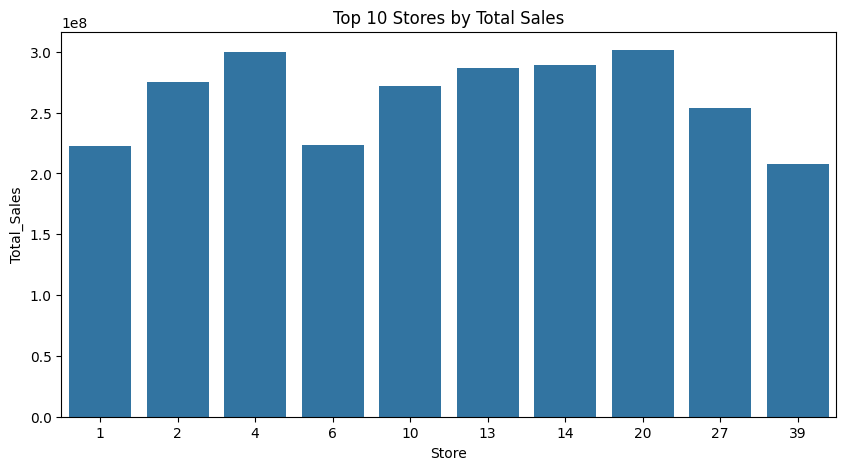

In [24]:
top10 = store_sales_pd.sort_values(
    by="Total_Sales",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x="Store",
    y="Total_Sales",
    data=top10
)

plt.title("Top 10 Stores by Total Sales")
plt.show()

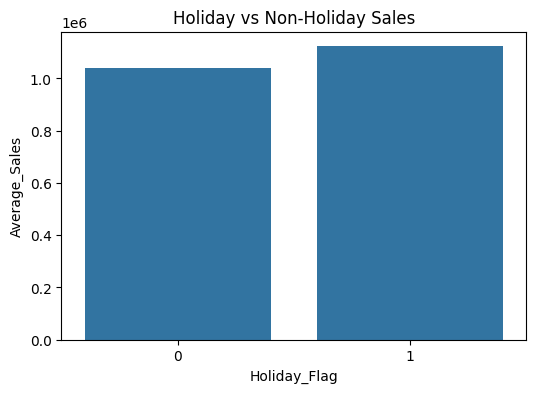

In [25]:
holiday_sales = df.groupBy(
    "Holiday_Flag"
).agg(
    avg("Weekly_Sales").alias("Average_Sales")
).toPandas()

plt.figure(figsize=(6,4))

sns.barplot(
    x="Holiday_Flag",
    y="Average_Sales",
    data=holiday_sales
)

plt.title("Holiday vs Non-Holiday Sales")
plt.show()

## 9. Business Insights

1. The Walmart sales dataset contains 6,435 records across multiple stores.

2. The average weekly sales across all stores was approximately $1.05 million.

3. Store 20 generated the highest total sales, followed by Store 4 and Store 14.

4. Holiday weeks recorded higher average sales compared to non-holiday weeks, indicating increased customer spending during holiday seasons.

5. Sales performance varied significantly across stores, highlighting differences in customer demand and store operations.

6. PySpark successfully processed and analyzed the dataset, demonstrating scalable data analysis techniques suitable for large datasets.

7. Business managers can use these insights to optimize inventory planning, staffing decisions, and promotional campaigns during high-sales periods.

## 10. Conclusion

This project successfully performed big data analysis on Walmart sales data using PySpark.

The dataset was processed using Spark DataFrames, and key business metrics such as total sales, average sales, store performance, and holiday sales impact were analyzed.

The analysis revealed that holiday periods positively influenced sales performance and identified the top-performing stores within the dataset.

This project demonstrates how PySpark can be used for scalable data processing and business intelligence, making it suitable for analyzing large datasets efficiently.
